In [ ]:
from pynq import Overlay
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt

# Load the bitstream
ol = Overlay("simple_nn.bit")

# Define the DMA object
# Note: Use ol.ip_dict.keys() if you forget the name
dma = ol.axi_dma_0

print("Hardware Loaded!")
print(f"IPs found: {list(ol.ip_dict.keys())}")

In [ ]:
from pynq import Overlay
import os

# ?? 1??????????
# ???????????? (simpleNN)
ol = Overlay("./simpleNN/simple_nn.bit")

print("Hardware Loaded Successfully!")
print(f"IPs found: {list(ol.ip_dict.keys())}")

In [ ]:
from pynq import Overlay
import os

# 1. ????????????
# ???????? simple_nn.bit ?????
print("Searching for your bitstream...")
!find / -name "simple_nn.bit" 2>/dev/null

# 2. ?????????????????
# ?????????????????????????????????
try:
    ol = Overlay("/root/jupyter_notebooks/simpleNN/simple_nn.bit")
    print("Success with path 1!")
except:
    try:
        ol = Overlay("/home/xilinx/jupyter_notebooks/simpleNN/simple_nn.bit")
        print("Success with path 2!")
    except:
        print("Still can't find it. Let's check current folder.")
        print(os.getcwd()) # ????????

In [ ]:
from pynq import Overlay
ol = Overlay("simple_nn.bit")
print("Bingo!")

In [ ]:
from pynq import Overlay
ol = Overlay("simple_nn.bit")
print("IPs in this design:", ol.ip_dict.keys())

In [ ]:
from pynq import Overlay

# ????? bit ????????????????
# ??????????simple_nn.bit
try:
    ol = Overlay("simple_nn.bit")
    print("Bingo! ????????")
    print("???? IP ??", ol.ip_dict.keys())
except Exception as e:
    print("?????????????")
    print(e)

In [ ]:
from pynq import Overlay
import os

# ????????????
full_path = os.getcwd()
bit_path = os.path.join(full_path, "simple_nn.bit")

print(f"Loading from: {bit_path}")

try:
    # ???????????? bitstream
    ol = Overlay(bit_path, download=True)
    print("Bingo! ????????")
    print("IPs found:", list(ol.ip_dict.keys()))
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")
    

In [ ]:
hwh_path = "/root/jupyter_notebooks/simpleNN/simple_nn.hwh"

try:
    with open(hwh_path, 'r') as f:
        # ??? 100 ???
        head = f.read(100)
        print("HWH file start:")
        print(head)
except Exception as e:
    print(f"Cannot read file: {e}")

In [ ]:
hwh_path = "/root/jupyter_notebooks/simpleNN/simple_nn.hwh"

# Read the file content
with open(hwh_path, 'r', encoding='utf-8', errors='ignore') as f:
    content = f.read()

# Remove anything before the first '<' (cleaning the header)
if content.find('<') != -1:
    clean_content = content[content.find('<'):]
    
    # Save the cleaned file
    with open(hwh_path, 'w', encoding='utf-8') as f:
        f.write(clean_content)
    print("Repair complete! The extra character has been removed.")
else:
    print("Could not find the start of XML content.")

In [ ]:
from pynq import Overlay
ol = Overlay("simple_nn.bit")
print("Bingo! IPs found:", list(ol.ip_dict.keys()))

In [ ]:
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. ????? (1024 ? 32-bit ??)
data_buffer = allocate(shape=(1024,), dtype=np.int32)

# 2. ?? DMA ??
dma = ol.axi_dma_0

# 3. ???? (????)
dma.recvchannel.transfer(data_buffer)

# 4. ????????
time.sleep(1)

# 5. ???????
print("DMA Status - Is Idle:", dma.recvchannel.idle)

plt.figure(figsize=(10, 4))
plt.plot(data_buffer[:500]) # ??? 500 ??
plt.title("Captured Signal from SimpleNN")
plt.grid(True)
plt.show()

print("First 10 values:", data_buffer[:10])

In [ ]:
from pynq import Overlay
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt
import time

# ??????? Overlay
ol = Overlay("simple_nn.bit")
dma = ol.axi_dma_0

print("Hardware and DMA are ready!")

In [ ]:
# 1. ?????
data_buffer = allocate(shape=(1024,), dtype=np.int32)

# 2. ????
dma.recvchannel.transfer(data_buffer)

# 3. ????
time.sleep(1)

# 4. ???????
print("DMA Status - Is Idle:", dma.recvchannel.idle)

plt.figure(figsize=(10, 4))
plt.plot(data_buffer[:500]) 
plt.title("Captured Signal from SimpleNN")
plt.grid(True)
plt.show()

print("First 10 values:", data_buffer[:10])

In [1]:
from pynq import Overlay
ol = Overlay("./simple_nn_v2.bit")

Status: Programming FPGA with v2 Bitstream...
Status: Overlay loaded successfully.
DMA Rx Running: True
Status: Starting DMA Transfer (S2MM)...
Error: DMA Transfer Timeout! (Check TLAST or Clock/Reset)


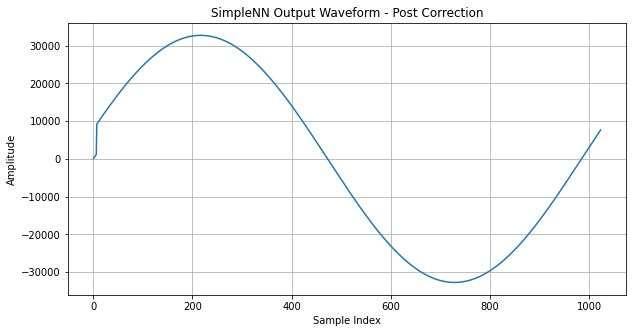

First 10 samples: [ 102  203  404  605  806 1007 1208 9224 9417 9609]


In [2]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Load the bitstream (v2)
# Ensure .bit and .hwh files are in the same folder with the same name
print("Status: Programming FPGA with v2 Bitstream...")
ol = Overlay("./simple_nn_v2.bit")
print("Status: Overlay loaded successfully.")

# 2. Define DMA and Memory Allocation
# Using np.int16 for 16-bit TDATA width from DDS/SimpleNN
dma = ol.axi_dma_0
data_len = 1024
data_buffer = allocate(shape=(data_len,), dtype=np.int16)

# 3. Check Hardware Status
# Ensure the DMA Channel is running
print(f"DMA Rx Running: {dma.recvchannel.running}")

# 4. Execute Data Transfer
print("Status: Starting DMA Transfer (S2MM)...")
dma.recvchannel.transfer(data_buffer)

# 5. Wait for completion with a Timeout safety
# This prevents the kernel from hanging if TLAST is missing
start_time = time.time()
timeout = 3.0  # seconds

while not dma.recvchannel.idle:
    if (time.time() - start_time) > timeout:
        print("Error: DMA Transfer Timeout! (Check TLAST or Clock/Reset)")
        break
else:
    print("Success: Data captured!")

# 6. Visualization
plt.figure(figsize=(10, 5))
plt.plot(data_buffer)
plt.title("SimpleNN Output Waveform - Post Correction")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 7. Raw Data Inspection
print("First 10 samples:", data_buffer[:10])

In [3]:
ol?